# Phishing URL Detection: Training Pipeline
This notebook provides a structured pipeline for analyzing URL data, extracting features, and training machine learning models for phishing detection.

In [1]:
# CELL 1: Environment Setup & Dependencies
%pip install -r requirements.txt xgboost nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2: Importing Libraries and Custom Modules
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Custom modules
from feature_extraction import extract_features_parallel, get_feature_names
from evaluate import (
    evaluate_model,
    plot_confusion_matrix,
    plot_model_comparison,
    plot_feature_importance,
    plot_class_distribution,
)

%matplotlib inline

In [3]:
# CELL 3: Data Loading and Heuristic Feature Extraction
def prepare_data(raw_csv_path="urldata.csv", extracted_csv_path="urldata_extracted.csv"):
    needs_extraction = True
    if os.path.exists(extracted_csv_path):
        try:
            extracted_count = pd.read_csv(extracted_csv_path, usecols=["target"]).shape[0]
            raw_count = pd.read_csv(raw_csv_path, usecols=["url"]).shape[0]
            if extracted_count >= int(raw_count * 0.99):
                print(f"Loading cached features ({extracted_count} rows)...")
                df = pd.read_csv(extracted_csv_path)
                needs_extraction = False
        except:
            os.remove(extracted_csv_path)

    if needs_extraction:
        print("Reading raw data...")
        df_raw = pd.read_csv(raw_csv_path)
        target_col = "result" if "result" in df_raw.columns else "label"
        targets = np.where(df_raw[target_col].str.lower() == "benign", 0, 1) if df_raw[target_col].dtype == object else df_raw[target_col].values
        urls = df_raw["url"].values
        features_list = extract_features_parallel(urls)
        df = pd.DataFrame(features_list)
        df["target"] = targets
        df["url"] = urls
        df.to_csv(extracted_csv_path, index=False)
    return df[get_feature_names()], df["target"]

X, y = prepare_data()
feature_names = X.columns.tolist()

Loading cached features (450176 rows)...


## Exploratory Data Analysis (EDA)

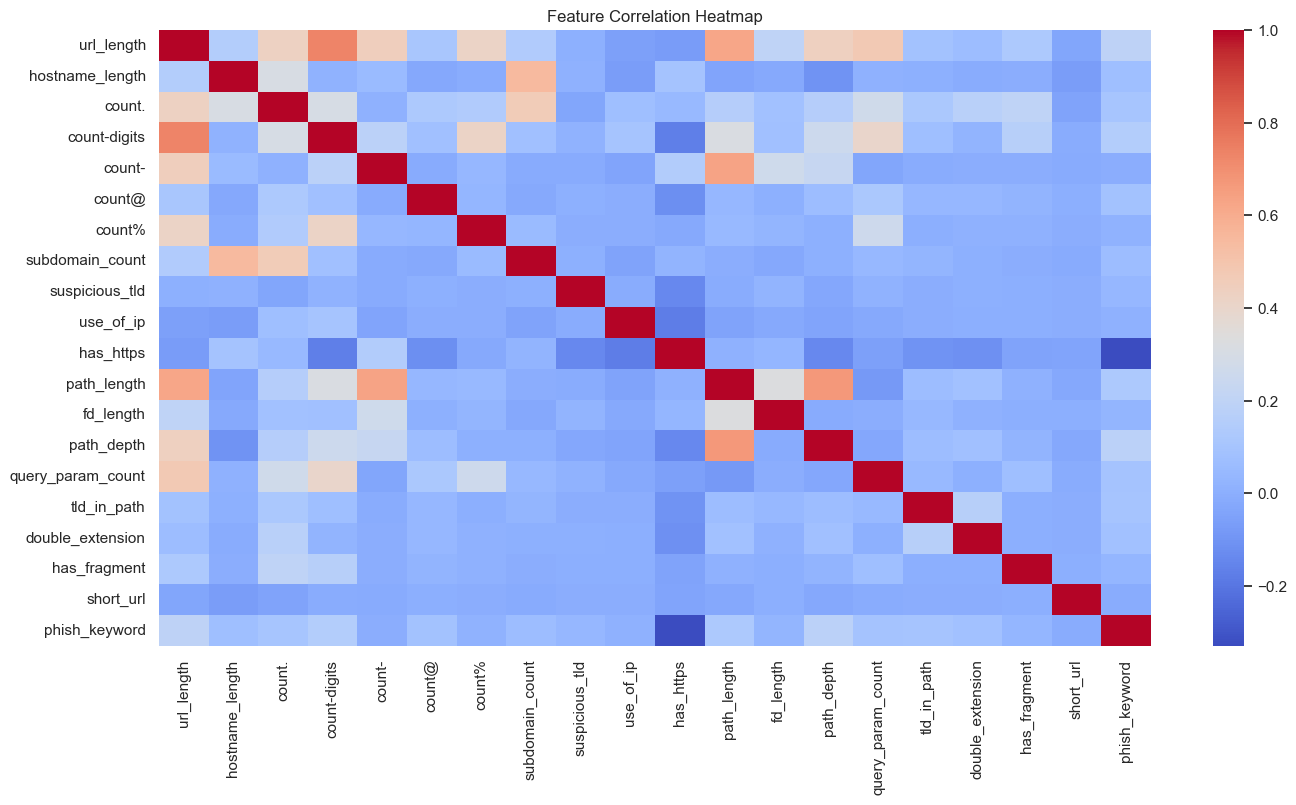

C:\Users\prani\AppData\Local\Temp\ipykernel_37676\2942794663.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['url_length'], palette='Set2')


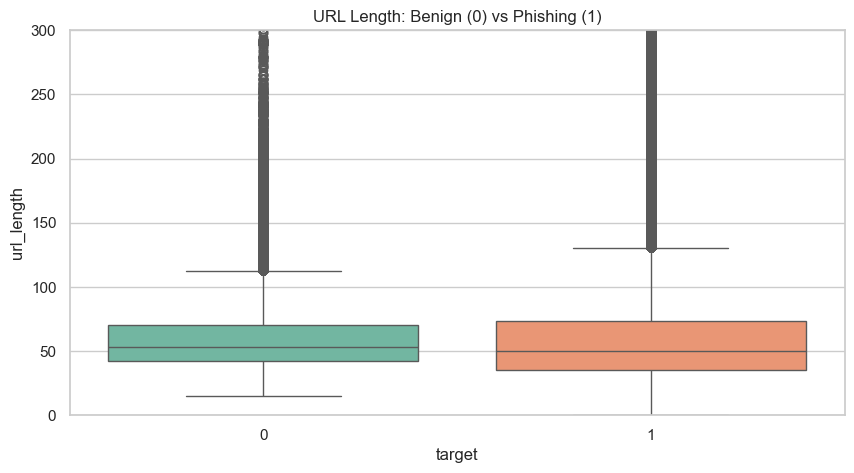

In [4]:
# CELL 4: Exploratory Data Analysis (EDA)
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(16, 8))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=y, y=X['url_length'], palette='Set2')
plt.title('URL Length: Benign (0) vs Phishing (1)')
plt.ylim(0, 300)
plt.show()

c:\Users\prani\Projects\ML-Based-Phishing-URL-Detection\evaluate.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_plot, x='Class', order=['Legitimate (0)', 'Phishing (1)'], palette="pastel")


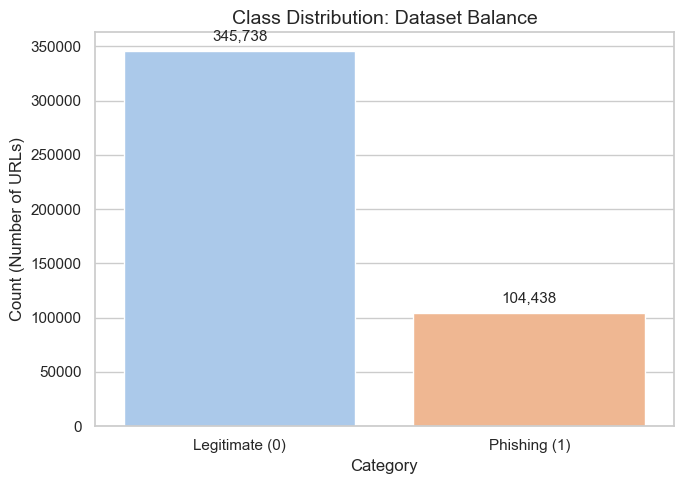

In [5]:
# CELL 5: Visualizing Dataset Class Balance
plot_class_distribution(y)

In [6]:
# CELL 6: Data Partitioning (Train/Test Split) and Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

--- Decision Tree Performance ---
Accuracy : 0.9932
Precision: 0.9861
Recall   : 0.9845
F1-Score : 0.9853



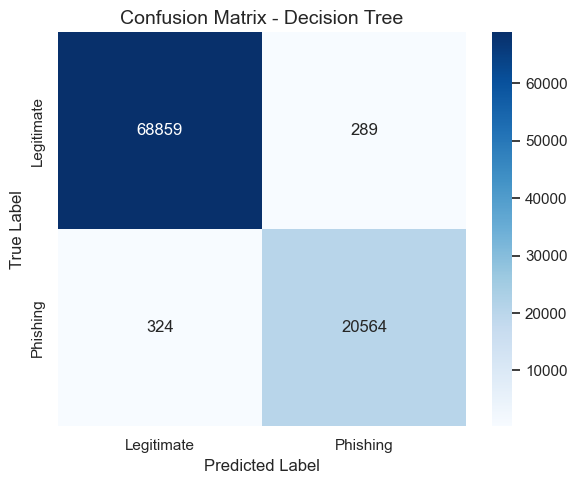

--- Random Forest Performance ---
Accuracy : 0.9956
Precision: 0.9972
Recall   : 0.9839
F1-Score : 0.9905



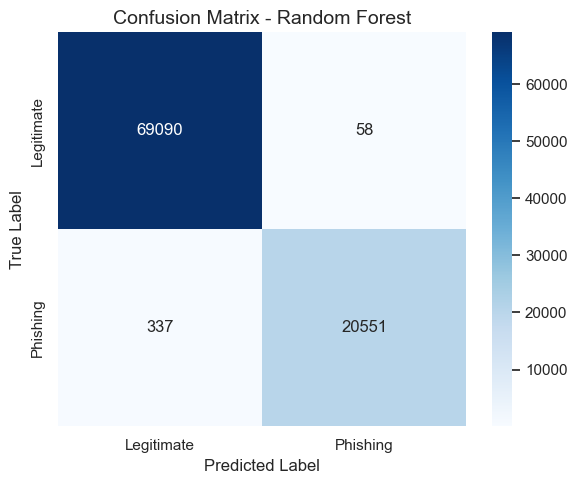

c:\Users\prani\Projects\ML-Based-Phishing-URL-Detection\evaluate.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


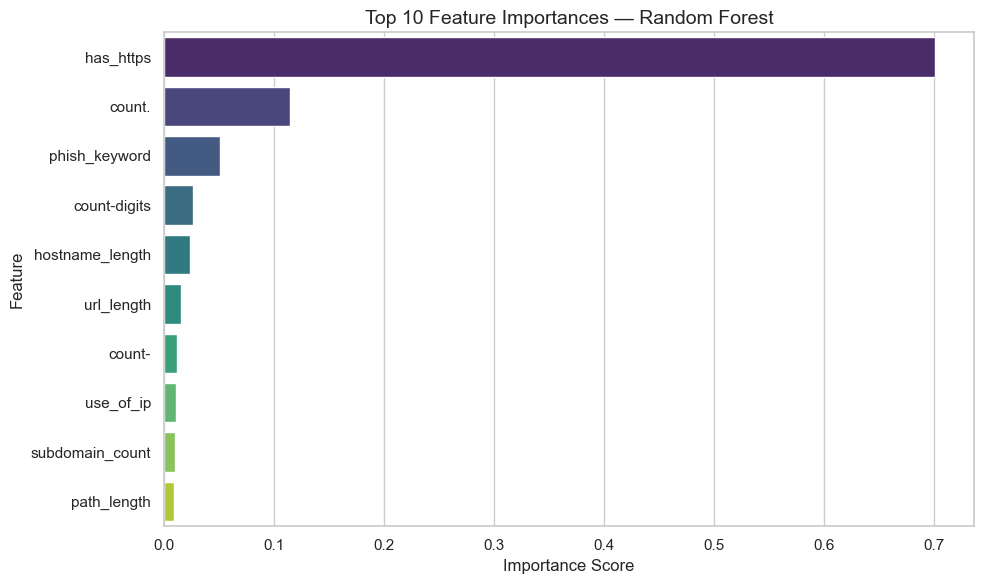

c:\Users\prani\Projects\ML-Based-Phishing-URL-Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Logistic Regression Performance ---
Accuracy : 0.9890
Precision: 0.9965
Recall   : 0.9561
F1-Score : 0.9759



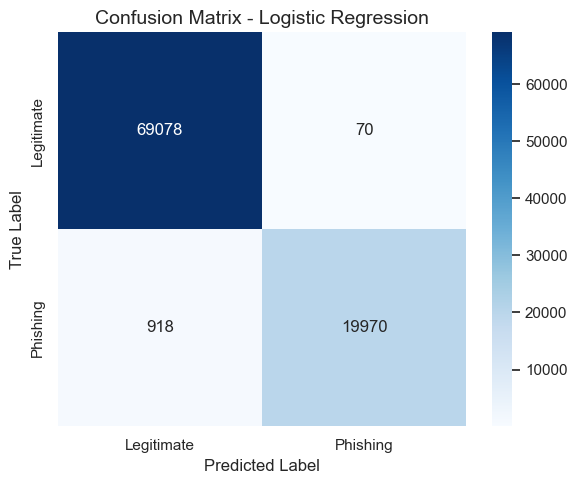

--- XGBoost Performance ---
Accuracy : 0.9952
Precision: 0.9960
Recall   : 0.9831
F1-Score : 0.9895



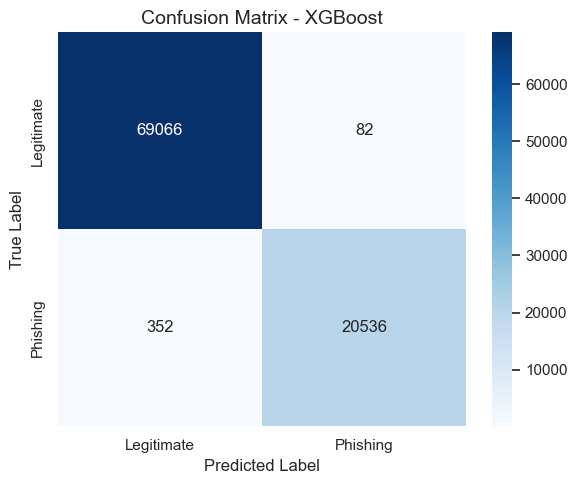

c:\Users\prani\Projects\ML-Based-Phishing-URL-Detection\evaluate.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


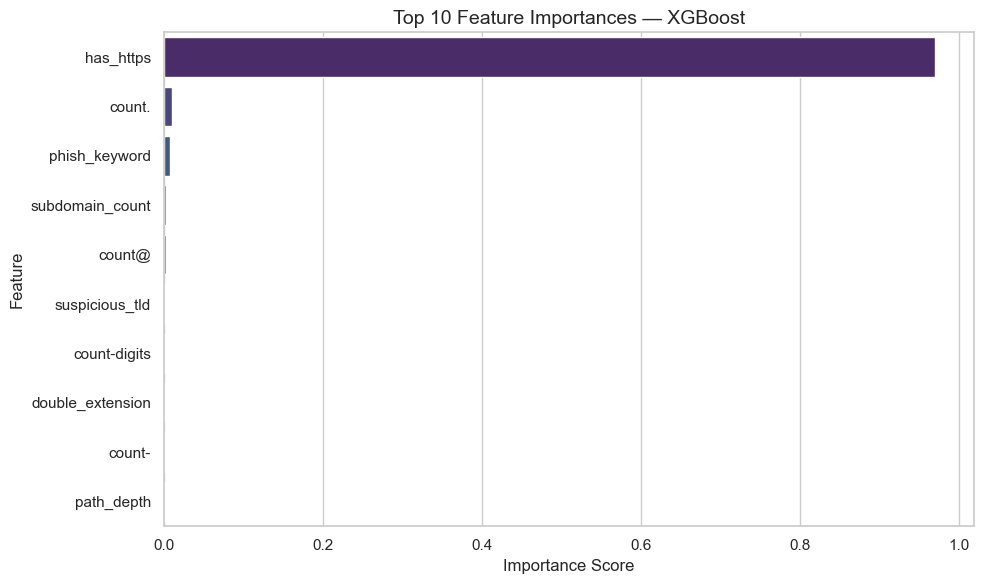

In [7]:
# CELL 7: Machine Learning Model Training & Initial Evaluation
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, tree_method="hist", random_state=42, n_jobs=-1),
}
results = {}
best_model_name, best_f1, best_model = None, 0.0, None

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    metrics = evaluate_model(name, y_test, y_pred)
    results[name] = metrics
    plot_confusion_matrix(name, y_test, y_pred)
    if metrics["F1"] > best_f1:
        best_f1, best_model_name, best_model = metrics["F1"], name, model
    if name in ("Random Forest", "XGBoost"):
        plot_feature_importance(model, feature_names, model_name=name)

## Model Comparison

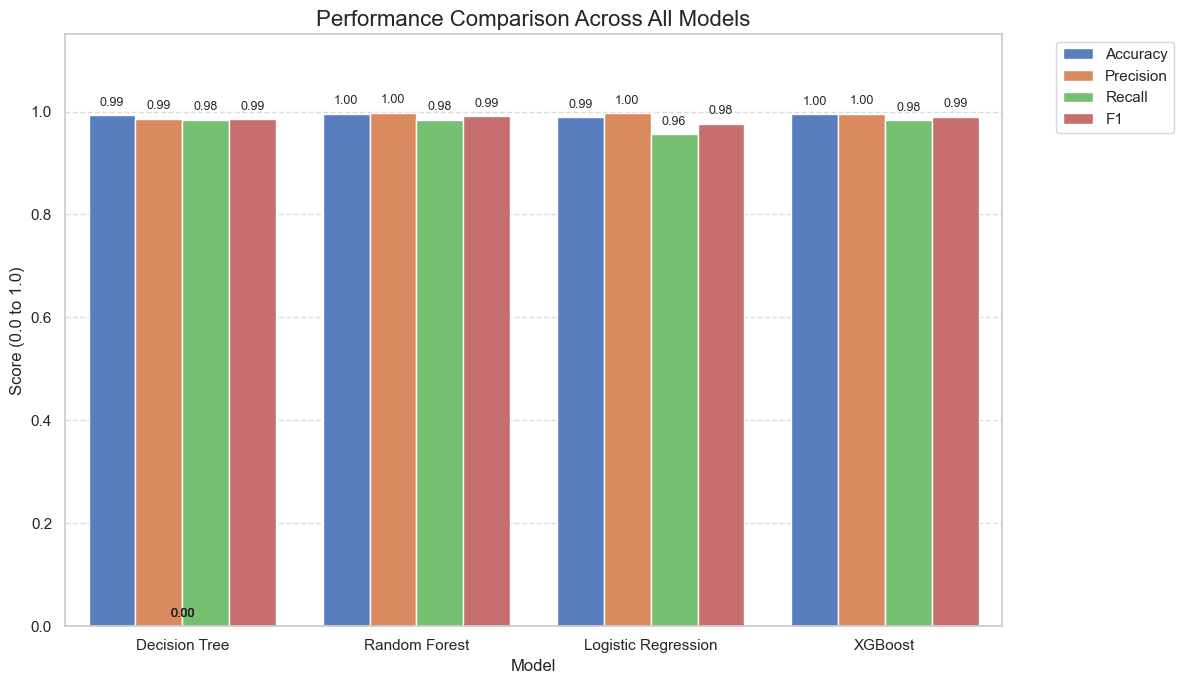

In [8]:
# CELL 8: Performance Comparison Dashboard
plot_model_comparison(results)

## Hyperparameter Tuning

In [10]:
# CELL 9: Hyperparameter Optimization (Fine-Tuning)
# Define search space based on the best performing model
if best_model_name == "XGBoost":
    param_grid = {
        "n_estimators": [200, 300],
        "max_depth": [4, 6],
        "learning_rate": [0.1, 0.2]
    }
elif best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [200, 300],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5]
    }
else:
    # No tuning defined for simpler models like Logistic Regression
    param_grid = {}

if param_grid:
    print(f"Fine-tuning {best_model_name} (n_iter=3)...")
    search = RandomizedSearchCV(best_model, param_grid, n_iter=3, cv=3, scoring="f1", n_jobs=-1, random_state=42)
    search.fit(X_train_scaled, y_train)
    best_model = search.best_estimator_
    print(f"\nBest Tuned Params for {best_model_name}: {search.best_params_}")
else:
    print(f"Skipping tuning for {best_model_name} (tuning not configured for this model type).")

Fine-tuning Random Forest (n_iter=3)...

Best Tuned Params for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}


In [ ]:
# CELL 10: Exporting the Final Production Model and Scaler
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
print("Model saved successfully.")